# Propagation of the error and flags

In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
import pandas as pd
import geopandas as gpd
from copy import deepcopy as dc
from matplotlib.ticker import LogLocator, FuncFormatter
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import os
import sys
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
sys.path.append(project_root)

from src.data import *
from src.post_process_functions import *
from src.hazard_def import *
from src.external_comparaison import *
from src.data_format import format_output, LIST_COLS

path_save_fig = DATA_FIGURE / "error_propagation"
#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

In [20]:
# 200 reports
res_name_llm = "post_processed_0-717_latest_reports_1quali_chunksize1000_Noneit_meta-llama_llama-4-scout-17b-16e-instruct_v230426_v180526_geo"

cols = [
    "appealCode",
    "reportDate",
    "impactSubtype",
    "impactValue",
    "impactValueMin",
    "impactValueMax",
    "impactValuePrecision",
    "impactUnit",
    "valueAnnotation",
    "location",
    "locationAnnotation",
    "locationPolygon",
    "locationLowestAdmin",
    "country_robust_iso3",
    "hazards",
    'startYear',
    'startMonth',
    'startDay',
    'endYear',
    'endMonth',
    'endDay'
]
df_llm_all_geo = gpd.read_file(os.path.join(DATA_OUT_PROC, res_name_llm+'.gpkg'), ignore_geometry=True)

## Extraction error

In [21]:
flag_cols = [col for col in df_llm_all_geo.columns if col.startswith("flag_") or col.startswith("valid_")]

In [23]:
# Create new flags that combine previous ones
df_llm_all_geo["flag_incorrect_unit"] = (
    df_llm_all_geo[["flag_partial_unit", "flag_unit_nonstd", "flag_percent"]]
    .fillna(False)
    .astype(bool)
    .any(axis=1)
 )

df_llm_all_geo["flag_unit_harmonize"] = (
    df_llm_all_geo[["flag_currency_conversion", "flag_people_unit_normalization",
                    "flag_non-SI_unit_standardization", "flag_SI_unit_standardization",
                    "flag_unit_conversion", "flag_unit_harmonization", "flag_remove_number_unit"]]
    .fillna(False)
    .astype(bool)
    .any(axis=1)
 )

In [24]:
dict_flag_name_plot = {
    "flag_value_not_in_text" : "Value not in text",
    "flag_percent" : "Unit Percentage",
    "flag_unit_not_in_text" : "Unit not in text",
    "flag_value_no_unit" : "Value without unit",
    "flag_incorrect_unit" : "Incorrect unit",
    "flag_unit_correction" : "Unit corrected",
}

In [33]:
flag_cols

['valid_errors_impactValue',
 'valid_errors_loc',
 'valid_errors_haz',
 'valid_errors_dates',
 'flag_value_not_in_text',
 'flag_impactSubtype_reclass',
 'flag_unknown_subtype',
 'flag_hazards_reclass',
 'flag_hazards_unknown',
 'flag_remove_number_unit',
 'flag_remove_number_unit_error',
 'flag_SI_unit_standardization',
 'flag_SI_unit_standardization_error',
 'flag_unit_harmonization',
 'flag_unit_conversion',
 'flag_unit_conversion_error',
 'flag_non-SI_unit_standardization_error',
 'flag_non-SI_unit_standardization',
 'flag_people_unit_normalization',
 'flag_currency_conversion',
 'flag_failed_currency_conversion',
 'flag_reclass_subtype_from_unit',
 'flag_impactSubtype_merged',
 'flag_unit_nonstd',
 'flag_value_no_unit',
 'flag_partial_unit',
 'flag_percent',
 'flag_remove_cat',
 'flag_remove_unit',
 'flag_response_unit',
 'flag_geocoding_country',
 'flag_geocoding_osm',
 'flag_pop_cntry']

In [26]:
## Validation
flags_valid_error = [
    "valid_errors_impactValue",
    "valid_errors_loc",
    "valid_errors_haz",
    "valid_errors_dates",
]
## Value
flags_quanti_value_error = ["flag_value_not_in_text", "flag_pop_cntry"]

## Unit
# flags_quanti_unit = ["flag_unit_not_in_text", "flag_value_no_unit", "flag_partial_unit", "flag_unit_nonstd", "flag_percent"]
flags_quanti_unit = ["flag_unit_not_in_text", "flag_value_no_unit", "flag_unit_incorrect_unit"]

flags_quanti_unit_correction = ["flag_remove_number_unit", "flag_unit_harmonization", "flag_unit_conversion",
                                "flag_SI_unit_standardization", "flag_non-SI_unit_standardization",
                                "flag_people_unit_normalization", "flag_currency_conversion"]

flags_subtypes = ["flag_impactSubtype_reclass", "flag_unknown_subtype", "flag_reclass_subtype_from_unit", "flag_impactSubtype_merged", "flag_response_unit"]
flags_hazard = ["flag_hazards_reclass", "flag_hazards_unknown"]
# flags_coherence = ["flag_pop_cntry"]
flags_remove = [
    "flag_remove_cat",
    "flag_remove_hazard",
    "flag_remove_unit",
    "flag_response_unit",
]

In [39]:
# separate between processing flags and error flags (that are later removed)
warning_flags = {
    "Extraction formatting error": [
        "valid_errors_impactValue",
        "valid_errors_loc",
        "valid_errors_haz",
        "valid_errors_dates",
    ],
    "Value & Unit processing": [
        # "valid_errors_impactValue",
        "flag_remove_number_unit",
        "flag_unit_harmonization",
        "flag_unit_conversion",
        "flag_SI_unit_standardization",
        "flag_non-SI_unit_standardization",
        "flag_people_unit_normalization",
        "flag_currency_conversion",
    ],
    "Subtype processing": [
        "flag_impactSubtype_reclass",
        "flag_reclass_subtype_from_unit",
        "flag_impactSubtype_merged",
    ],
    "Hazard processing": ["flag_hazards_reclass"],
    "Dates processing": [],
    "Location processing": [
        "flag_geocoding_country",
        "flag_geocoding_osm",
    ],
}
remove_flags = {
    "Value & Unit remove": [
        "flag_value_not_in_text",
        "flag_pop_cntry",
        "flag_remove_number_unit_error",
        "flag_SI_unit_standardization_error",
        "flag_non-SI_unit_standardization_error",
        "flag_unit_conversion_error",
        "flag_failed_currency_conversion",
        'flag_remove_unit',
        'flag_response_unit',
    ],
    "Value & unit remove - qualitative conversion": [
        'flag_value_no_unit',
        'flag_partial_unit',
    ],
    "Subtype remove": [
        "flag_unknown_subtype",
        "flag_remove_cat",
    ],
    "Hazard remove": [
        "flag_hazards_unknown",
    ]}


In [40]:
# Correct the flag_value_not_in_text, it should be True/False and not 1/0
def correct_flag_value_not_in_text(row):
    if row['flag_value_not_in_text'] in [1, '1.0', True, 'True']:
        return True
    elif row['flag_value_not_in_text'] in [0, '0.0', False, 'False', None, np.nan]:
        return False
    else:
        return row['flag_value_not_in_text']  # Return the original value if it's not recognized

df_llm_all_geo['flag_value_not_in_text'] = df_llm_all_geo.apply(correct_flag_value_not_in_text, axis=1)

In [41]:
# The quanti rows are the rows with a value in the impactValue column
df_llm_all_geo_quanti = df_llm_all_geo[df_llm_all_geo["impactValue"].notna()].copy()

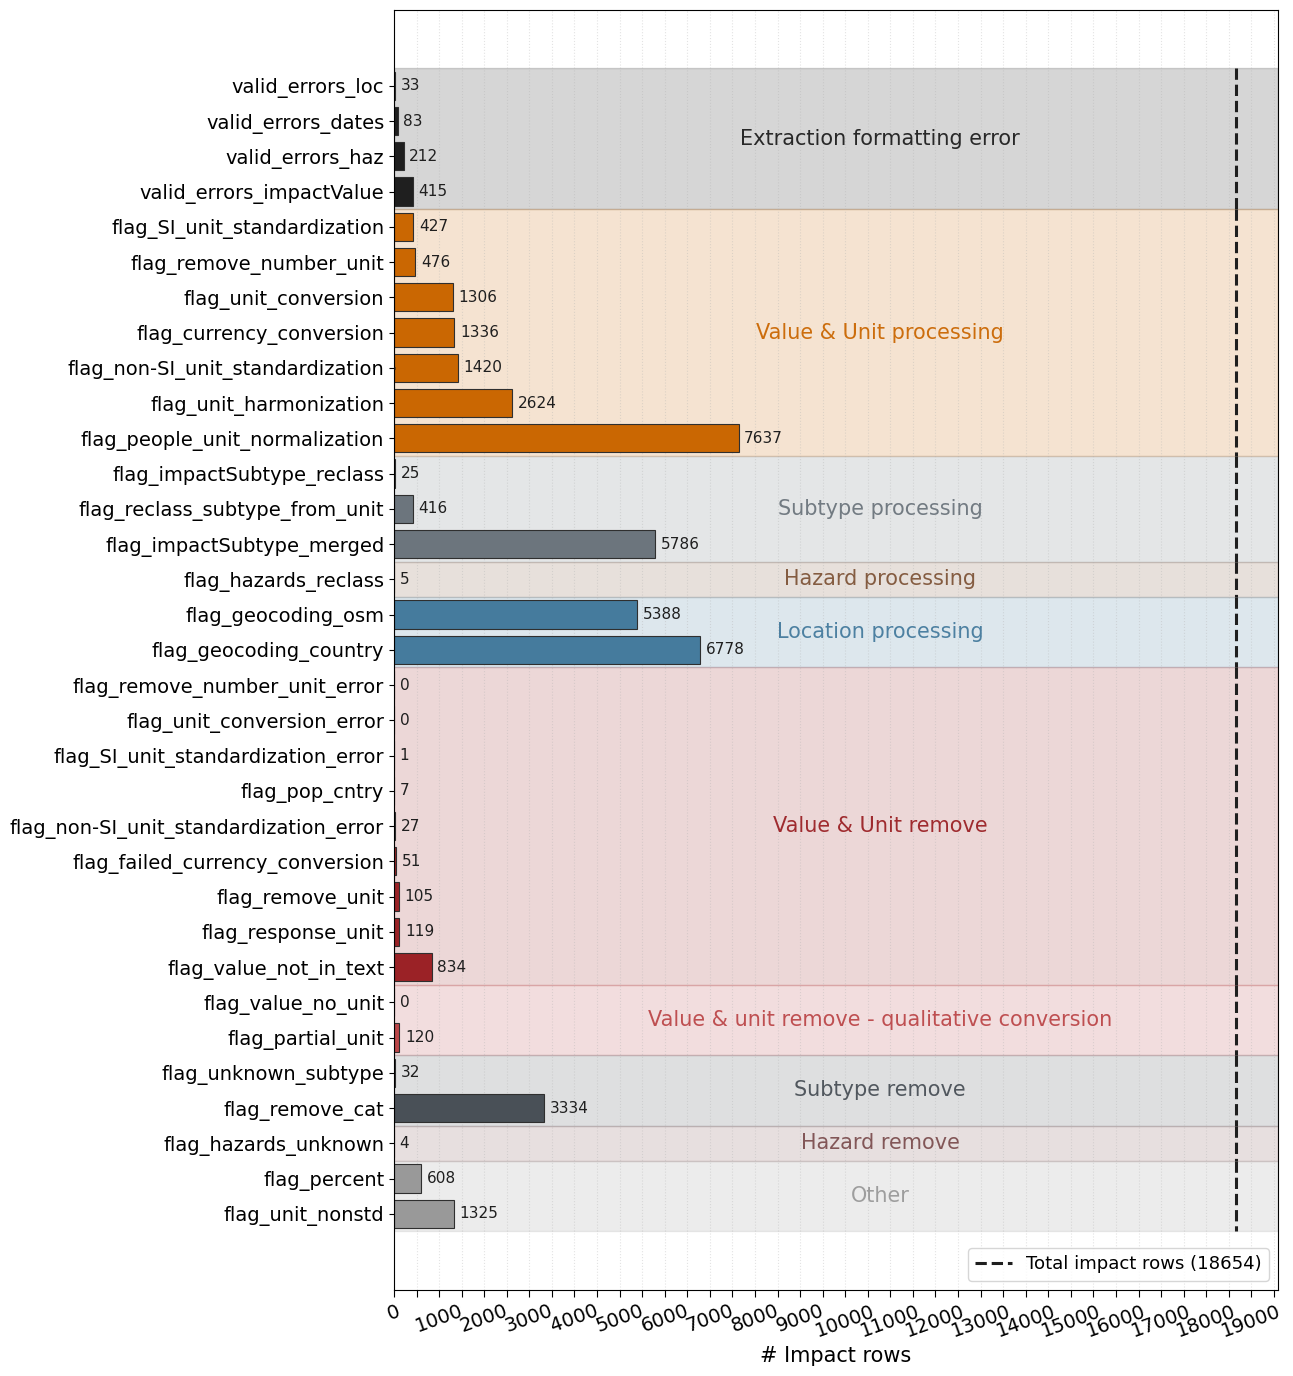

In [42]:
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Build groups directly from dictionaries
# -----------------------------------------------------------------------------

flag_groups = list(warning_flags.items()) + list(remove_flags.items())

# -----------------------------------------------------------------------------
# Colors
# -----------------------------------------------------------------------------

category_palette = {
    "Extraction formatting error": "#1f1f1f",
    "Value & Unit processing": "#ca6702",
    "Subtype processing": "#6c757d",
    "Hazard processing": "#7f5539",
    "Dates processing": "#adb5bd",
    "Location processing": "#457b9d",
    "Value & Unit remove": "#9b2226",
    "Value & unit remove - qualitative conversion": "#bc4749",
    "Subtype remove": "#495057",
    "Hazard remove": "#7d4f50",
    "Other": "#999999",
}

# -----------------------------------------------------------------------------
# Use only the full dataframe
# -----------------------------------------------------------------------------

source_df = df_llm_all_geo

# -----------------------------------------------------------------------------
# Order flags by group and frequency
# -----------------------------------------------------------------------------

known_flags = {flag for _, group_flags in flag_groups for flag in group_flags}

base_flags = list(flag_cols)
remaining_flags = [f for f in base_flags if f not in known_flags]

ordered_flags = []
category_spans = []
flag_to_category = {}

for group_index, (group_name, group_flags) in enumerate(flag_groups):

    existing_flags = [flag for flag in group_flags if flag in source_df.columns]

    if not existing_flags:
        continue

    group_counts = (
        source_df[existing_flags]
        .fillna(False)
        .astype(bool)
        .sum()
        .sort_values(ascending=True)
    )

    start = len(ordered_flags)

    ordered_flags.extend(group_counts.index.tolist())

    for flag in group_counts.index:
        flag_to_category[flag] = group_name

    end = len(ordered_flags) - 1

    category_spans.append((group_name, start, end, group_index))

# -----------------------------------------------------------------------------
# Add uncategorized flags
# -----------------------------------------------------------------------------

if remaining_flags:

    remaining_counts = (
        source_df[remaining_flags]
        .fillna(False)
        .astype(bool)
        .sum()
        .sort_values(ascending=True)
    )

    start = len(ordered_flags)

    ordered_flags.extend(remaining_counts.index.tolist())

    for flag in remaining_counts.index:
        flag_to_category[flag] = "Other"

    end = len(ordered_flags) - 1

    category_spans.append(("Other", start, end, len(category_spans)))

# -----------------------------------------------------------------------------
# Counts
# -----------------------------------------------------------------------------

flag_counts = pd.Series(
    [int(source_df[flag].fillna(False).astype(bool).sum()) for flag in ordered_flags],
    index=ordered_flags,
    dtype=int,
)

bar_colors = [
    category_palette.get(
        flag_to_category.get(flag, "Other"),
        "#666666",
    )
    for flag in ordered_flags
]

# -----------------------------------------------------------------------------
# Figure setup
# -----------------------------------------------------------------------------

total_rows = len(source_df)

max_x = max(
    total_rows,
    flag_counts.max() if len(flag_counts) else 0,
)

x_padding = max(
    2,
    int(np.ceil(max_x * 0.05)),
)

x_max = max_x + x_padding

x_tick_step = 500
x_ticks = np.arange(
    0,
    x_max + x_tick_step,
    x_tick_step,
)

fig_height = max(
    5.5,
    0.42 * len(ordered_flags),
)

fig, ax = plt.subplots(figsize=(13, fig_height))

ax.set_axisbelow(True)

# -----------------------------------------------------------------------------
# Background shading
# -----------------------------------------------------------------------------

for group_name, start, end, _ in category_spans:

    ax.axhspan(
        start - 0.5,
        end + 0.5,
        color=category_palette.get(
            group_name,
            "#d9d9d9",
        ),
        alpha=0.18,
        zorder=0,
    )

# -----------------------------------------------------------------------------
# Group labels
# -----------------------------------------------------------------------------

label_x = x_max * 0.55

for group_name, start, end, _ in category_spans:

    ax.text(
        label_x,
        (start + end) / 2,
        group_name,
        ha="center",
        va="center",
        fontsize=15,
        color=category_palette.get(
            group_name,
            "#1f1f1f",
        ),
        alpha=0.95,
        zorder=1.5,
    )

# -----------------------------------------------------------------------------
# Bars
# -----------------------------------------------------------------------------

y_positions = np.arange(len(ordered_flags))

ax.barh(
    y_positions,
    flag_counts.values,
    color=bar_colors,
    edgecolor="#2f2f2f",
    linewidth=0.8,
    zorder=2,
)

# -----------------------------------------------------------------------------
# Value labels + error overlays
# -----------------------------------------------------------------------------

for y_pos, flag_name, flag_count in zip(
    y_positions,
    ordered_flags,
    flag_counts.values,
):

    ax.annotate(
        f"{flag_count}",
        xy=(flag_count, y_pos),
        xytext=(4, 0),
        textcoords="offset points",
        va="center",
        ha="left",
        fontsize=11,
        color="#1f1f1f",
        zorder=4,
    )

    error_col = f"{flag_name}_error"

    if error_col in source_df.columns:

        error_count = int(source_df[error_col].fillna(False).astype(bool).sum())

        if error_count > 0:

            ax.hlines(
                y_pos,
                0,
                min(error_count, flag_count),
                colors="#1f1f1f",
                linestyles="--",
                linewidth=2.2,
                zorder=3,
            )

# -----------------------------------------------------------------------------
# Total rows reference line
# -----------------------------------------------------------------------------

for _, start, end, _ in category_spans:

    ax.vlines(
        total_rows,
        start - 0.5,
        end + 0.5,
        color="#1f1f1f",
        linestyle="--",
        linewidth=2.2,
        zorder=4,
    )

# -----------------------------------------------------------------------------
# Styling
# -----------------------------------------------------------------------------

ax.set_xticks(x_ticks)
ax.set_xticklabels([str(tick) if tick % 1000 == 0 else "" for tick in x_ticks])

ax.tick_params(
    axis="x",
    which="major",
    length=5,
    labelrotation=20,
    labelsize=14,
)

ax.set_xlim(0, x_max)

ax.set_yticks(y_positions)
ax.set_yticklabels(
    ordered_flags,
    fontsize=14,
)

ax.set_xlabel(
    "# Impact rows",
    fontsize=15,
)

ax.invert_yaxis()

ax.grid(
    axis="x",
    linestyle=":",
    alpha=0.35,
    zorder=1,
)

# -----------------------------------------------------------------------------
# Legend
# -----------------------------------------------------------------------------

ax.legend(
    handles=[
        Line2D(
            [0],
            [0],
            color="#1f1f1f",
            linestyle="--",
            linewidth=2.2,
            label=f"Total impact rows ({total_rows})",
        ),
    ],
    fontsize=13,
    loc="lower right",
    frameon=True,
)

plt.tight_layout()
plt.show()

valid_errors_loc 33
valid_errors_dates 83
valid_errors_haz 212
valid_errors_impactValue 415
flag_pop_cntry 7
flag_value_not_in_text 834
flag_value_no_unit 0
flag_SI_unit_standardization 416
flag_remove_number_unit 474
flag_non-SI_unit_standardization 1220
flag_unit_conversion 1250
flag_currency_conversion 1332
flag_unit_harmonization 2448
flag_people_unit_normalization 6975
flag_impactSubtype_reclass 25
flag_unknown_subtype 32
flag_response_unit 119
flag_reclass_subtype_from_unit 416
flag_impactSubtype_merged 5786
flag_hazards_unknown 4
flag_hazards_reclass 5
flag_remove_unit 105
flag_response_unit 119
flag_remove_cat 3334
flag_SI_unit_standardization_error 1
flag_remove_number_unit_error 0
flag_non-SI_unit_standardization_error 23
flag_unit_conversion_error 0


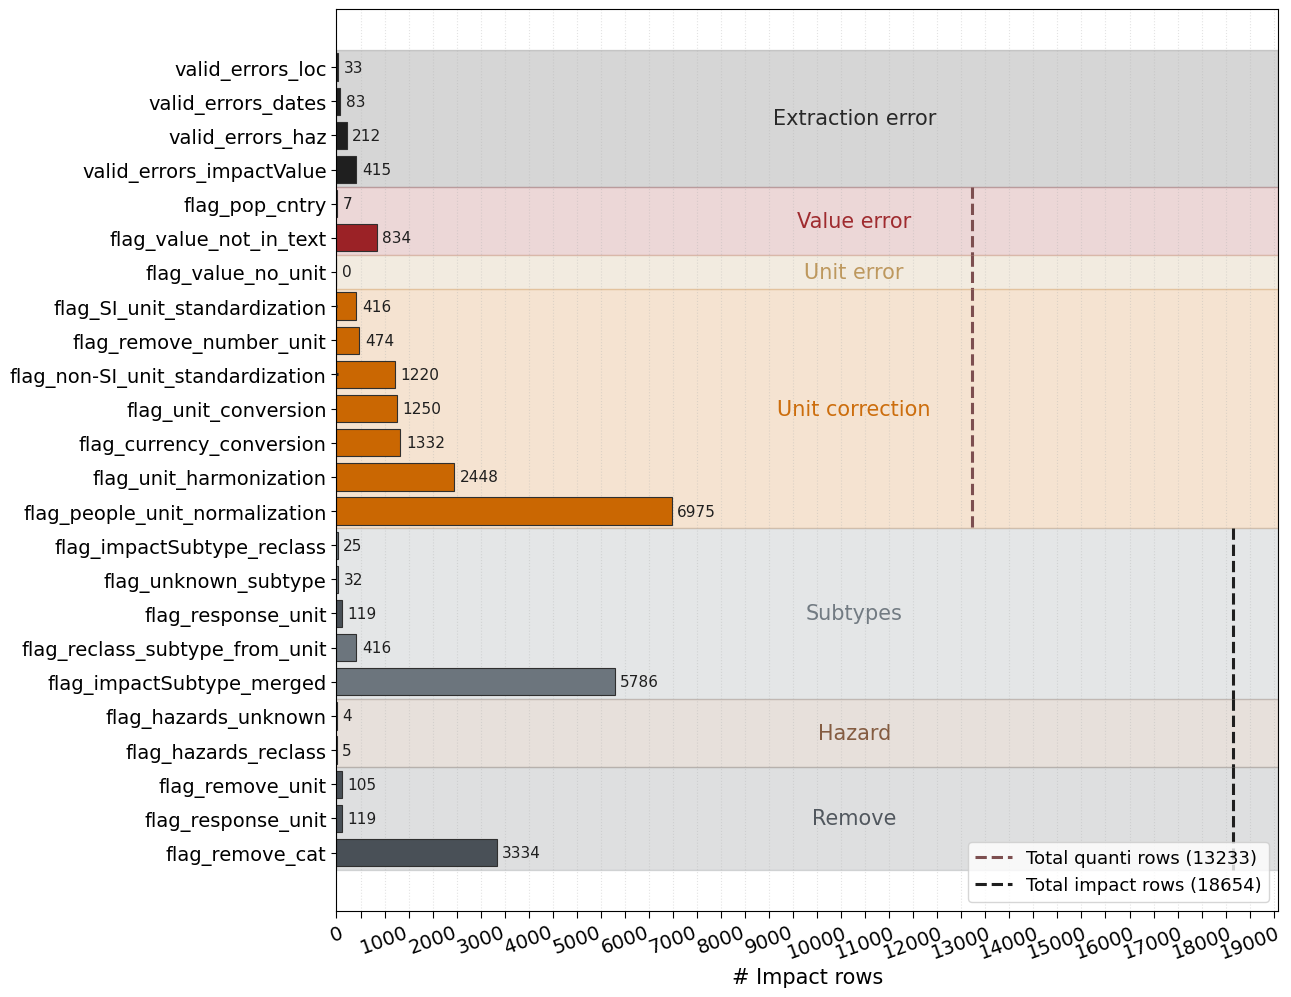

In [ ]:
flag_groups = [
    ("Extraction error", flags_valid_error),
    ("Inconsistent value", flags_quanti_value_error),
    ("Unit error", flags_quanti_unit),
    ("Unit processing", flags_quanti_unit_correction),
    ("Subtypes", flags_subtypes),
    ("Hazard", flags_hazard),
    #("Coherence", flags_coherence),
    ("Remove", flags_remove),
]
category_palette = {
    "Extraction error": "#1f1f1f",
    "Inconsistent value": "#9b2226",
    "Unit error": "#bb9457",
    "Unit processing": "#ca6702",
    #"Remove quanti": "#7d4f50",
    "Subtypes": "#6c757d",
    "Hazard": "#7f5539",
    #"Coherence": "#adb5bd",
    "Remove": "#495057",
}

quanti_groups = {"Inconsistent value", "Unit error", "Unit processing", "Remove quanti"}
other_groups = {"Subtypes", "Hazard", "Coherence", "Remove"}

# Keep the group order used in the notebook and add any remaining flags at the end.
known_flags = {flag for _, group in flag_groups for flag in group}
base_flags = [flag for flag in flag_cols ]#if not flag.endswith("_error")]
remaining_flags = [flag for flag in base_flags if flag not in known_flags]

ordered_flags = []
category_spans = []
flag_to_category = {}
for group_index, (group_name, group_flags) in enumerate(flag_groups):
    existing_flags = [flag for flag in group_flags if flag in base_flags]
    if not existing_flags:
        continue
    source_df = df_llm_all_geo_quanti if group_name in quanti_groups else df_llm_all_geo
    group_counts = (
        source_df[existing_flags]
        .fillna(False)
        .astype(bool)
        .sum()
        .sort_values(ascending=True)
    )
    start = len(ordered_flags)
    ordered_flags.extend(group_counts.index.tolist())
    for flag in group_counts.index.tolist():
        flag_to_category[flag] = group_name
    end = len(ordered_flags) - 1
    category_spans.append((group_name, start, end, group_index))

flag_counts = []
for flag in ordered_flags:
    group_name = flag_to_category.get(flag, "")
    source_df = df_llm_all_geo_quanti if group_name in quanti_groups else df_llm_all_geo
    print(flag, source_df[flag].fillna(False).astype(bool).sum())
    flag_counts.append(int(source_df[flag].fillna(False).astype(bool).sum()))
flag_counts = pd.Series(flag_counts, index=ordered_flags, dtype=int)

bar_colors = [category_palette.get(flag_to_category.get(flag, ""), "#666666") for flag in ordered_flags]

total_impact_rows = len(df_llm_all_geo)
total_quanti_rows = len(df_llm_all_geo_quanti)
max_x = int(max(total_impact_rows, total_quanti_rows, flag_counts.max())) if len(flag_counts) else max(total_impact_rows, total_quanti_rows)
x_padding = max(2, int(np.ceil(max_x * 0.05)))
x_max = max_x + x_padding
x_tick_step = 500
x_ticks = np.arange(0, x_max + x_tick_step, x_tick_step)

fig_height = max(5.5, 0.42 * len(ordered_flags))
fig, ax = plt.subplots(figsize=(13, fig_height))
ax.set_axisbelow(True)

for group_name, start, end, _ in category_spans:
    ax.axhspan(
        start - 0.5,
        end + 0.5,
        color=category_palette.get(group_name, "#d9d9d9"),
        alpha=0.18,
        zorder=0,
    )

label_x = x_max * 0.55
for group_name, start, end, _ in category_spans:
    ax.text(
        label_x,
        (start + end) / 2,
        group_name,
        ha="center",
        va="center",
        fontsize=15,
        color=category_palette.get(group_name, "#1f1f1f"),
        alpha=0.95,
        zorder=1.5,
    )

y_positions = np.arange(len(ordered_flags))
ax.barh(y_positions, flag_counts.values, color=bar_colors, edgecolor="#2f2f2f", linewidth=0.8, zorder=2)

for y_pos, flag_name, flag_count in zip(y_positions, ordered_flags, flag_counts.values):
    ax.annotate(
        f"{int(flag_count)}",
        xy=(flag_count, y_pos),
        xytext=(4, 0),
        textcoords="offset points",
        va="center",
        ha="left",
        fontsize=11,
        color="#1f1f1f",
        zorder=4,
    )
    error_col = f"{flag_name}_error"
    if error_col in df_llm_all_geo.columns:
        source_df = df_llm_all_geo_quanti if flag_to_category.get(flag_name, "") in quanti_groups else df_llm_all_geo
        error_count = int(source_df[error_col].fillna(False).astype(bool).sum())
        print(error_col, error_count)
        if error_count > 0:
            ax.hlines(
                y_pos,
                0,
                min(error_count, flag_count),
                colors="#1f1f1f",
                linestyles="--",
                linewidth=2.2,
                zorder=3,
            )

for group_name, start, end, _ in category_spans:
    if group_name in quanti_groups:
        ax.vlines(
            total_quanti_rows,
            start - 0.5,
            end + 0.5,
            color="#7d4f50",
            linestyle="--",
            linewidth=2.2,
            zorder=4,
        )
    elif group_name in other_groups:
        ax.vlines(
            total_impact_rows,
            start - 0.5,
            end + 0.5,
            color="#1f1f1f",
            linestyle="--",
            linewidth=2.2,
            zorder=4,
        )

ax.set_xticks(x_ticks)
ax.set_xticklabels([f"{tick}" if tick % 1000 == 0 else "" for tick in x_ticks])
ax.tick_params(axis="x", which="major", length=5, labelrotation=20, labelsize=14)
ax.set_xlim(0, x_max)
ax.set_yticks(y_positions)
ax.set_yticklabels(ordered_flags, fontsize=14)
ax.set_xlabel("# Impact rows", fontsize=15)
ax.invert_yaxis()
ax.grid(axis="x", linestyle=":", alpha=0.35, zorder=1)

ax.legend(handles=[
    Line2D([0], [0], color="#7d4f50", linestyle="--", linewidth=2.2, label=f"Total quanti rows ({total_quanti_rows})"),
    Line2D([0], [0], color="#1f1f1f", linestyle="--", linewidth=2.2, label=f"Total impact rows ({total_impact_rows})"),
], fontsize=13, loc="lower right", frameon=True)

plt.tight_layout()
#fig.savefig(path_save_fig / "flags.png", transparent=True, bbox_inches='tight', dpi=300)
#fig.savefig(path_save_fig / "flags.svg", format="svg", transparent=True, bbox_inches='tight', dpi=300)
#fig.savefig(path_save_fig / "flags.pdf", format="pdf", transparent=True, bbox_inches='tight', dpi=300)
plt.show()

# Geocoding 

In [6]:
nominatim_output = pd.read_pickle(DATA_OUT_PROC / "nominatim_output_220526.pkl")
geocoding_unique = gpd.read_file(DATA_OUT_PROC / "geocode_unique_220526.gpkg")

In [26]:
geocoding_unique.location.nunique()

8898

In [35]:
# Aggregate per unique location so repeated split rows count as one location.
existing_flag_cols = [flag for flag in flag_cols if flag in geocoding_unique.columns]
grouped_locations = geocoding_unique.groupby("location", dropna=False)

location_summary = grouped_locations.agg(
    finest_level=("finest_level", lambda s: pd.to_numeric(s, errors="coerce").max()),
).reset_index()
for flag in existing_flag_cols:
    location_summary[flag] = grouped_locations[flag].apply(
        lambda s: int(pd.to_numeric(s, errors="coerce").fillna(0).astype(bool).all())
    ).to_numpy()

location_summary["flag_count"] = location_summary[existing_flag_cols].sum(axis=1) if existing_flag_cols else 0
location_summary

,location,finest_level,flag_geocoding_country,flag_geocoding_osm,flag_count
0,'Eua,1.0,0,0,0
1,1 de Diciembre,2.0,0,0,0
2,"1,144 villages",0.0,1,0,1
3,"1,208 villages across 106 districts in 15 prov...",0.0,1,0,1
4,"1,215 barangays",2.0,0,1,1
...,...,...,...,...,...
8893,Đurđevik,2.0,0,1,1
8894,Šabac,2.0,0,0,0
8895,Žitorađa,0.0,1,0,1
8896,Živinice,2.0,0,1,1


In [36]:
location_summary.finest_level.value_counts().sort_index()

finest_level
0.0    3248
1.0    2439
2.0    3207
Name: count, dtype: int64

In [41]:
location_summary.groupby("finest_level")["flag_geocoding_country"].sum().sort_index()

finest_level
0.0    3127
1.0       0
2.0       0
Name: flag_geocoding_country, dtype: int64

In [42]:
location_summary.groupby("finest_level")["flag_geocoding_osm"].sum().sort_index()

finest_level
0.0       0
1.0     448
2.0    1337
Name: flag_geocoding_osm, dtype: int64

In [38]:
len(location_summary)

8898